In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [9]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/jaeynaagodawat/cvcat/cv.jpg


In [12]:
image = cv2.imread("/kaggle/input/datasets/jaeynaagodawat/cvcat/cv.jpg")

In [14]:
print(image.shape)
print(image.dtype)

(1008, 678, 3)
uint8


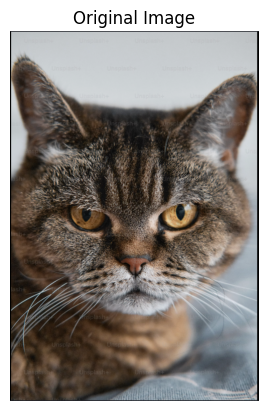

In [15]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Original Image")
plt.show()

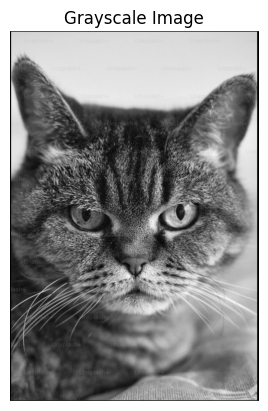

In [16]:

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale Image")
plt.show()

In [18]:
s_x=np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

s_y=np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 0, 2]
])

In [21]:
def convolution(image, kernel):
    
    image_height, image_width = image.shape

    
    kernel_height, kernel_width = kernel.shape

  
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    
    padded_image = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="constant",
        constant_values=0
    )

   
    output = np.zeros((image_height, image_width), dtype=np.float32)

    
    for i in range(image_height):
        for j in range(image_width):

           
            region = padded_image[
                i:i + kernel_height,
                j:j + kernel_width
            ]

            
            output[i, j] = np.sum(region * kernel)

    return output

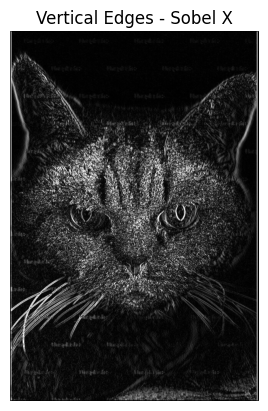

In [24]:

edges_x = convolution(gray, s_x)


edges_x = np.abs(edges_x)


edges_x = np.clip(edges_x, 0, 255)

plt.imshow(edges_x, cmap="gray")
plt.axis("off")
plt.title("Vertical Edges - Sobel X")
plt.show()

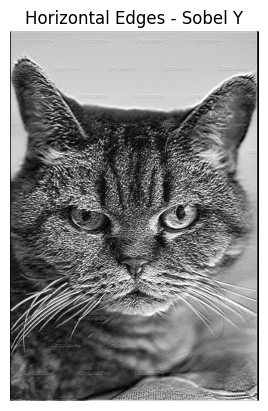

In [25]:

edges_y = convolution(gray, s_y)

edges_y = np.abs(edges_y)


edges_y = np.clip(edges_y, 0, 255)

plt.imshow(edges_y, cmap="gray")
plt.axis("off")
plt.title("Horizontal Edges - Sobel Y")
plt.show()

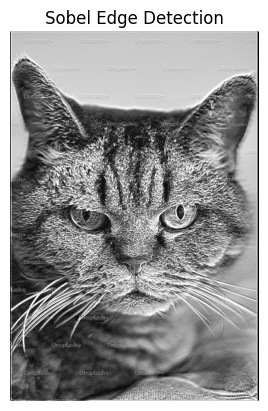

In [26]:

gradient_magnitude = np.sqrt(
    edges_x**2 + edges_y**2
)


gradient_magnitude = np.clip(
    gradient_magnitude,
    0,
    255
)

plt.imshow(gradient_magnitude, cmap="gray")
plt.axis("off")
plt.title("Sobel Edge Detection")
plt.show()

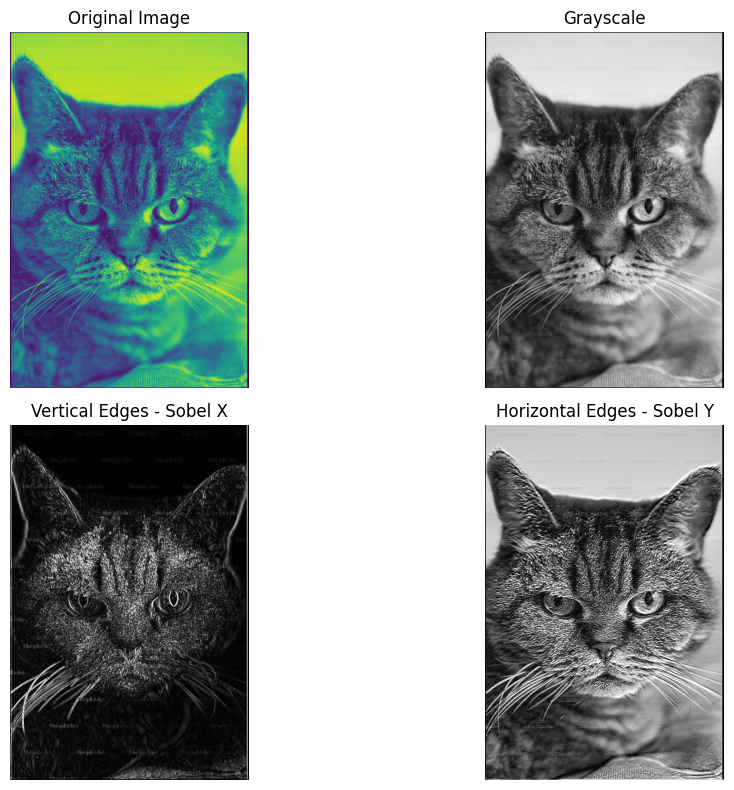

In [28]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray)
plt.axis("off")
plt.title("Original Image")

plt.subplot(2, 2, 2)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale")

plt.subplot(2, 2, 3)
plt.imshow(edges_x, cmap="gray")
plt.axis("off")
plt.title("Vertical Edges - Sobel X")

plt.subplot(2, 2, 4)
plt.imshow(edges_y, cmap="gray")
plt.axis("off")
plt.title("Horizontal Edges - Sobel Y")

plt.tight_layout()
plt.show()

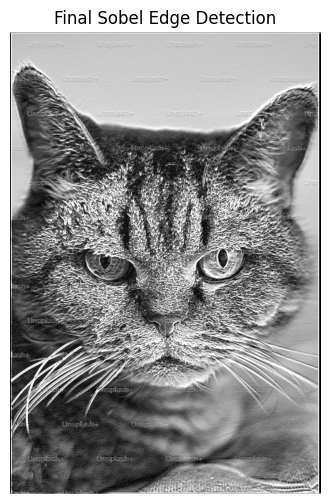

In [29]:
plt.figure(figsize=(6, 6))

plt.imshow(gradient_magnitude, cmap="gray")
plt.axis("off")
plt.title("Final Sobel Edge Detection")

plt.show()